# Lecture 14 - Data Storytelling

**Story:** *The Great Demographic Transition (1950-2023)*

Aplicacao pratica das tecnicas da Lecture 14 sobre o dataset de mortalidade infantil e fertilidade.

Estrutura em 3 atos (slide 35):
1. **Context** - Qual e o problema? Qual a situacao inicial?
2. **Heart** - O que os dados revelam? Onde esta a complicacao?
3. **Action** - O que isso significa? Qual a conclusao?

Tecnicas aplicadas: preattentive attributes (destaque seletivo), small multiples com escala compartilhada, titulos analiticos (que ja contam o achado), anotacoes/call-outs, contexto explicito (fonte, unidade, periodo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

GRAY = '#cccccc'
ACCENT = '#1f77b4'
HIGHLIGHT = '#d62728'
TEXT = '#333333'

SOURCE = 'Source: Our World in Data / Gapminder | Unit: deaths per 100 live births, children per woman | Period: 1950-2023'

df = pd.read_csv('Dataset/dataset_countries.csv')
df = df[df['year'] >= 1950].copy()
df.head()

,entity,code,year,child_mortality_rate,fertility_rate_hist,continent,sub_region
0,Afghanistan,AFG,1950,37.13,7.248,Asia,Southern Asia
1,Afghanistan,AFG,1951,37.13,7.260,Asia,Southern Asia
2,Afghanistan,AFG,1952,37.13,7.260,Asia,Southern Asia
3,Afghanistan,AFG,1953,37.13,7.266,Asia,Southern Asia
4,Afghanistan,AFG,1954,37.13,7.254,Asia,Southern Asia


## Act 1 - Context (Setting & Hook)

> Em 1950, **1 a cada 5 criancas** no mundo nao chegava aos 5 anos.
> Hoje, e **menos de 1 em 25**.

Esse e o ponto de partida da historia. O gancho e a magnitude da queda.

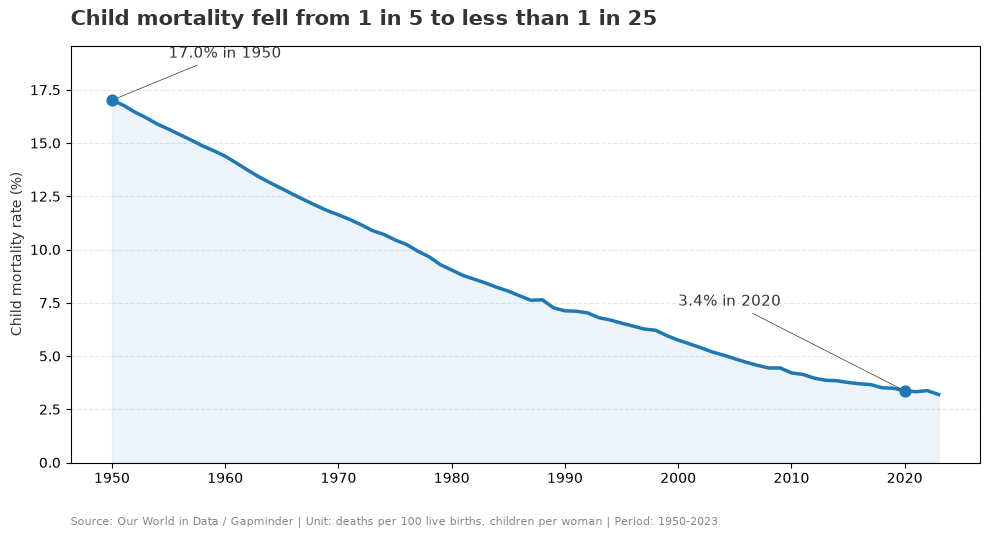

In [9]:
world = df.groupby('year', as_index=False).agg(
    mortality=('child_mortality_rate', 'mean'),
    fertility=('fertility_rate_hist', 'mean'),
)

y_1950 = world.loc[world['year'] == 1950, 'mortality'].iloc[0]
y_2020 = world.loc[world['year'] == 2020, 'mortality'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(world['year'], world['mortality'], color=ACCENT, linewidth=2.5)
ax.fill_between(world['year'], world['mortality'], alpha=0.08, color=ACCENT)

ax.scatter([1950, 2020], [y_1950, y_2020], color=ACCENT, zorder=5, s=60)
ax.annotate(f'{y_1950:.1f}% in 1950',
            xy=(1950, y_1950), xytext=(1955, y_1950 + 2),
            fontsize=11, color=TEXT,
            arrowprops=dict(arrowstyle='-', color=TEXT, lw=0.5))
ax.annotate(f'{y_2020:.1f}% in 2020',
            xy=(2020, y_2020), xytext=(2000, y_2020 + 4),
            fontsize=11, color=TEXT,
            arrowprops=dict(arrowstyle='-', color=TEXT, lw=0.5))

ax.set_ylim(0, world['mortality'].max() * 1.15)
ax.set_xlabel('')
ax.set_ylabel('Child mortality rate (%)', color=TEXT)
ax.set_title('Child mortality fell from 1 in 5 to less than 1 in 25',
             fontsize=15, fontweight='bold', color=TEXT, loc='left', pad=15)
ax.text(0, 1.03, '',
        transform=ax.transAxes, fontsize=11, color='#666666')
ax.text(0, -0.15, SOURCE, transform=ax.transAxes, fontsize=8, color='#888888')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Act 2 - Heart (Rising Insights)

> A media global esconde a complicacao: **a transicao nao aconteceu na mesma velocidade em todo lugar.**

Para revelar essa heterogeneidade, usamos *small multiples* (slide 26): mesma estrutura, mesmas escalas, so a categoria muda. A repeticao ajuda o leitor a focar nos dados em vez do desenho do grafico.

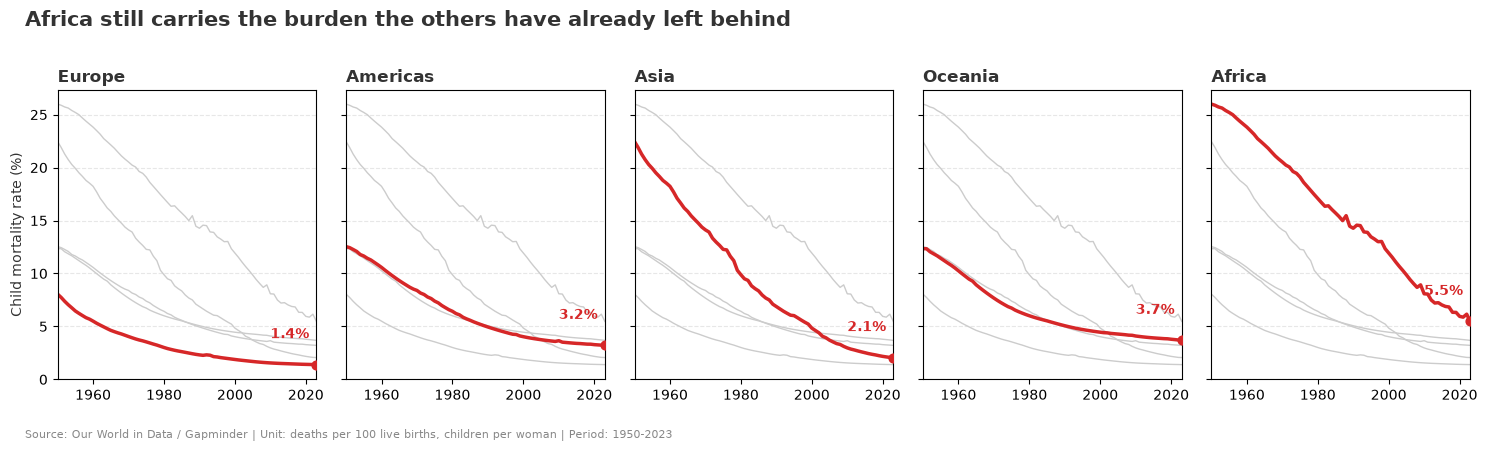

In [8]:
continent_year = (
    df.groupby(['continent', 'year'], as_index=False)
      .agg(mortality=('child_mortality_rate', 'mean'))
)

continents = ['Europe', 'Americas', 'Asia', 'Oceania', 'Africa']
continents = [c for c in continents if c in continent_year['continent'].unique()]

y_max = continent_year['mortality'].max() * 1.05
x_min, x_max = continent_year['year'].min(), continent_year['year'].max()

fig, axes = plt.subplots(1, len(continents), figsize=(15, 4), sharey=True)

for ax, cont in zip(axes, continents):
    for other in continents:
        sub = continent_year[continent_year['continent'] == other]
        ax.plot(sub['year'], sub['mortality'], color=GRAY, linewidth=1)
    sub = continent_year[continent_year['continent'] == cont]
    ax.plot(sub['year'], sub['mortality'], color=HIGHLIGHT, linewidth=2.5)

    last = sub.iloc[-1]
    ax.scatter(last['year'], last['mortality'], color=HIGHLIGHT, zorder=5, s=40)
    ax.text(last['year'] - 2, last['mortality'] + 2.5,
            f"{last['mortality']:.1f}%", color=HIGHLIGHT, fontsize=10,
            fontweight='bold', ha='right')

    ax.set_title(cont, fontsize=12, fontweight='bold', color=TEXT, loc='left')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Child mortality rate (%)', color=TEXT)

fig.suptitle('Africa still carries the burden the others have already left behind',
             fontsize=15, fontweight='bold', color=TEXT, x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.96, '',
         fontsize=11, color='#666666')
fig.text(0.02, -0.05, SOURCE, fontsize=8, color='#888888')

plt.tight_layout()
plt.show()

## Animated trajectory (Hans Rosling style)

> A imagem estatica do Ato 3 mostra o **destino**. A animacao mostra a **jornada**.

Cada bolinha e um pais. O ano aparece como titulo grande e avanca quadro a quadro; a medida que o tempo passa, os paises migram do canto superior-direito (alta mortalidade, alta fertilidade) para o inferior-esquerdo. Cor por continente. Inspirado nas animacoes classicas de Hans Rosling / Gapminder.

O GIF e salvo como `demographic_transition.gif` na pasta do notebook.

In [12]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from IPython.display import HTML

anim_df = df.dropna(subset=['child_mortality_rate', 'fertility_rate_hist', 'continent']).copy()
years = sorted(anim_df['year'].unique())

continent_colors = {
    'Africa':   '#d62728',
    'Asia':     '#1f77b4',
    'Europe':   '#2ca02c',
    'Americas': '#ff7f0e',
    'Oceania':  '#9467bd',
}

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.set_xlim(0, anim_df['fertility_rate_hist'].max() + 0.3)
ax.set_ylim(0, anim_df['child_mortality_rate'].max() * 1.05)
ax.set_xlabel('Fertility rate (children per woman)', color=TEXT)
ax.set_ylabel('Child mortality rate (%)', color=TEXT)
ax.grid(linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

for cont, color in continent_colors.items():
    ax.scatter([], [], color=color, label=cont, s=40)
ax.legend(loc='upper right', frameon=False, fontsize=10, title='Continent')

ax.text(0, 1.03, '',
        transform=ax.transAxes, fontsize=11, color='#666666')
ax.text(0, -0.12, SOURCE, transform=ax.transAxes, fontsize=8, color='#888888')

scatter = ax.scatter([], [], s=40, alpha=0.75, edgecolors='white', linewidths=0.5)
title = ax.set_title(str(years[0]), fontsize=28, fontweight='bold', color=TEXT, loc='left', pad=15)

def update(year):
    yd = anim_df[anim_df['year'] == year]
    scatter.set_offsets(list(zip(yd['fertility_rate_hist'], yd['child_mortality_rate'])))
    scatter.set_facecolors([continent_colors.get(c, '#888') for c in yd['continent']])
    title.set_text(str(year))
    return scatter, title

anim = animation.FuncAnimation(fig, update, frames=years, interval=200, blit=False)
anim.save('demographic_transition.gif', writer=PillowWriter(fps=2)) #SE QUISER DEIXAR O GIF MAIS RÁPIDO GABRIEL, É SÓ AUMENTAR O VALOR DO FPS
plt.close()

HTML('<img src="demographic_transition.gif">')

## Resolution - Solution & Next Steps

**O que a historia conta:**

1. **Context.** A mortalidade infantil global caiu de ~22% em 1950 para ~3% em 2020 - uma das maiores conquistas em saude publica da historia recente.
2. **Heart.** A queda nao foi uniforme: Europa e Asia ja completaram a transicao, mas a Africa ainda carrega o peso que os outros continentes deixaram para tras.
3. **Aha moment.** Mortalidade e fertilidade caem juntas. A trajetoria do Brasil, Japao, India e Suecia mostra o mesmo movimento - do canto superior-direito (alta mortalidade, alta fertilidade) para o inferior-esquerdo. A Nigeria comecou a se mover, mas ainda esta no caminho.

**Limitacoes (slide 30 - context matters):**
- Medias por pais escondem desigualdades internas (renda, raca, regiao).
- Dados pre-1950 sao mais escassos e foram excluidos da analise.
- Correlacao entre fertilidade e mortalidade nao e causalidade direta - ambas sao consequencia de fatores comuns (saude, educacao, renda).

**Proximo passo analitico:** quantificar quanto tempo a Africa Subsaariana leva, no ritmo atual, para alcancar o nivel de mortalidade que a America Latina atingiu em 2020. Esse seria o gancho de uma proxima historia.